# This is a Level 1 Header

execute:
  echo: false
  warning: false


In [1]:
# python imports
from crim_intervals import * 
from crim_intervals import importScore 
from crim_intervals import main_objs
from community import community_louvain
from copy import deepcopy
from IPython.display import SVG
# from ipywidgets import interact
import altair as alt
import glob as glob
import crim_intervals
import crim_intervals.visualizations as viz
import numpy as np
import os
import pandas as pd
import re
import networkx as nx
import requests

MYDIR = ("saved_csv")
CHECK_FOLDER = os.path.isdir(MYDIR)

# If folder doesn't exist, then create it.
if not CHECK_FOLDER:
    os.makedirs(MYDIR)
    print("created folder : ", MYDIR)

else:
    print(MYDIR, "folder already exists.")
    
MUSDIR = ("Music_Files")
CHECK_FOLDER = os.path.isdir(MUSDIR)

# If folder doesn't exist, then create it.
if not CHECK_FOLDER:
    os.makedirs(MUSDIR)
    print("created folder : ", MUSDIR)

else:
    print(MUSDIR, "folder already exists.")
    

saved_csv folder already exists.
Music_Files folder already exists.


In [3]:
# for image rendering
# alt.renderers.enable('jupyterlab')
alt.renderers.enable('default')
import plotly.io as pio
pio.renderers.default = "plotly_mimetype+notebook_connected"

# Adding Louvain Communities
def add_communities(G):
    G = deepcopy(G)
    partition = community_louvain.best_partition(G)
    nx.set_node_attributes(G, partition, "group")
    return G

In [2]:
file_list = glob.glob('Music_Files/*')
file_list = sorted(file_list)
file_list

model = importScore(file_list[3])
file_list

['Music_Files/CRIM_Mass_0001_1.mei',
 'Music_Files/CRIM_Mass_0001_2.mei',
 'Music_Files/CRIM_Mass_0001_3.mei',
 'Music_Files/CRIM_Mass_0001_4.mei',
 'Music_Files/CRIM_Mass_0001_5.mei',
 'Music_Files/CRIM_Mass_0002_1.mei',
 'Music_Files/CRIM_Mass_0002_2.mei',
 'Music_Files/CRIM_Mass_0002_3.mei',
 'Music_Files/CRIM_Mass_0002_4.mei',
 'Music_Files/CRIM_Mass_0002_5.mei',
 'Music_Files/CRIM_Mass_0003_1.mei',
 'Music_Files/CRIM_Mass_0003_2.mei',
 'Music_Files/CRIM_Mass_0003_3.mei',
 'Music_Files/CRIM_Mass_0003_4.mei',
 'Music_Files/CRIM_Mass_0003_5.mei',
 'Music_Files/CRIM_Mass_0004_1.mei',
 'Music_Files/CRIM_Mass_0004_2.mei',
 'Music_Files/CRIM_Mass_0004_3.mei',
 'Music_Files/CRIM_Mass_0004_4.mei',
 'Music_Files/CRIM_Mass_0004_5.mei',
 'Music_Files/CRIM_Mass_0005_1.mei',
 'Music_Files/CRIM_Mass_0005_2.mei',
 'Music_Files/CRIM_Mass_0005_3.mei',
 'Music_Files/CRIM_Mass_0005_4.mei',
 'Music_Files/CRIM_Mass_0005_5.mei',
 'Music_Files/CRIM_Mass_0006_1.mei',
 'Music_Files/CRIM_Mass_0006_2.mei',
 

### Level 3 Header:  the Model Entry Ngrams

In [5]:
n=3
combineUnisons=False
kind='d'
thematic = True
anywhere = False

# find entries for model
nr = model.notes(combineUnisons=combineUnisons)
mel = model.melodic(df=nr, kind=kind, compound=False, unit=0, end=False)
mod_mel_ngrams = model.ngrams(df=mel, n=n, exclude=['Rest'])
mod_entry_ngrams = model.entries(df=mel, n=n, thematic=thematic, anywhere=anywhere, exclude=['Rest'])

mod_entry_ngrams = mod_entry_ngrams.fillna('')
# mod_entry_ngrams

### Another Level 3 header: Comparison of Ngrams across pieces

Here we will compare the ngrams of the model with each of the Mass movements.

This shows the % of ngrams shared between the pieces, first in tabular form and then as a color chart.



In [62]:
# the model.  in the list above this is piece #5
mod_corp = CorpusBase([file_list[3]])

# # the mass movements  in the list above these are all pieces EXCEPT #5
# mass_corp = CorpusBase(file_list[:5] + file_list[6:])

mass_corp = CorpusBase(file_list[:3])

# run the comparison, passing in both sets as parameters:
# be sure to set the N for length of ngrams!
soggetto_cross_plot_narrow = mod_corp.modelFinder(n=3,
                                                  masses=mass_corp, models=mod_corp,
                                                 anywhere=False,
                                                 thematic=True)

# view the result
soggetto_cross_plot_narrow

Model,CRIM_Mass_0006_4
Mass,
CRIM_Mass_0006_1,0.744186
CRIM_Mass_0006_2,0.690909
CRIM_Mass_0006_3,0.420168


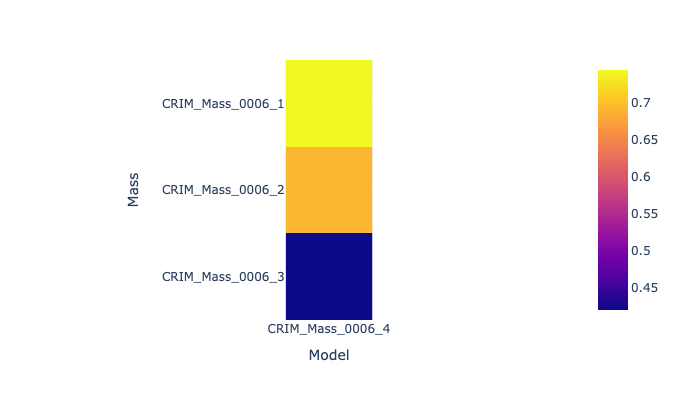

In [63]:
fig = px.imshow(soggetto_cross_plot_narrow, width=400, height=400)
fig


## A Level 2 Header: Conclusions from Melodic Ngrams

It seems from the above that in the case of the Kyrie, Gloria, and Credo movements, the melodic motives of Daser's Mass are more closely related to the motet those of Lasso's Mass.  On the other hand, Lasso's Sanctus and Agnus are more closely related to the motet than the corresponding movements of Daser's Mass.

Does this correspond to what human analysts notice about these movements?



# Cross Plots of ALL Movements

Here we compare all movements in the corpus to each other.

This shows which of the Mass movements are related to each other, too.  Again first in tabular then graphical form.

In [64]:

# Full Cross Plot of All movements
corpus = CorpusBase(file_list)
soggetto_cross_plot = corpus.modelFinder(n=4)
# soggetto_cross_plot.loc[

# selected_data = soggetto_cross_plot.iloc[:, :5].join(soggetto_cross_plot.iloc[:, -5 /
central_portion = soggetto_cross_plot.iloc[0:5, 5:10]

central_portion

Model,CRIM_Mass_0007_1,CRIM_Mass_0007_2,CRIM_Mass_0007_3,CRIM_Mass_0007_4,CRIM_Mass_0007_5
Mass,,,,,
CRIM_Mass_0006_1,0.488889,0.761111,0.577778,0.666667,0.627778
CRIM_Mass_0006_2,0.383886,0.601896,0.478673,0.469194,0.606635
CRIM_Mass_0006_3,0.330097,0.448544,0.370874,0.376699,0.405825
CRIM_Mass_0006_4,0.305921,0.440789,0.427632,0.309211,0.450658
CRIM_Mass_0006_5,0.232143,0.60119,0.279762,0.333333,0.464286


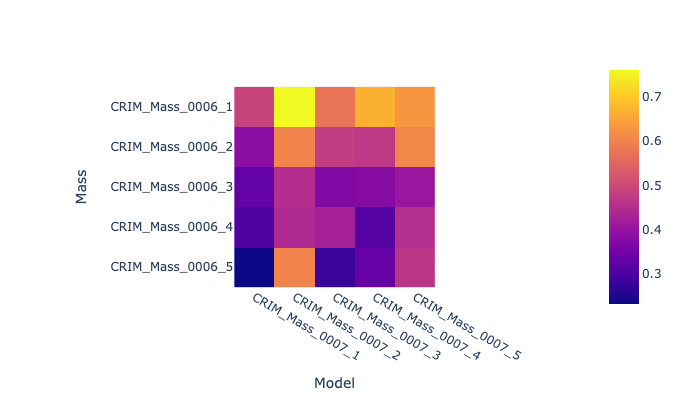

In [65]:
fig = px.imshow(central_portion, width=400, height=400)
fig

## Conclusions from Melodic Ngrams of All Movements

It seems from the above that in the case of the Kyrie, Gloria, and Credo movements, the melodic motives of Daser's Mass are more closely related to the motet those of Lasso's Mass.  On the other hand, Lasso's Sanctus and Agnus are more closely related to the motet than the corresponding movements of Daser's Mass.

Does this correspond to what human analysts notice about these movements?

We might NOT be surprised to see that the Agnus movements share 60% of the ngrams (they are short movements after all).  But it IS suprising to see that the Gloria and Credo movements share over 70% of their ngrams, despite the fact that these are quite long, and despite the fact that Lasso's Gloria and Credo share only about 25% of their ngrams with the model.  This suggests, in brief, that Lasso's Gloria and Credo are very connected with the corresponding movements of Daser's Mass.



## Level 2:  Heat Maps

Now let's see *where* the connections appear.  We do this with heat maps of ngrams.

First let's get the model from the list of files.  It's number "3" in our list.

Here are the basic settings:

```python
n=3
combineUnisons=False
kind='d'
thematic = False
anywhere = True
```

In [66]:
n=3
combineUnisons=False
kind='d'
thematic = False
anywhere = True


In [67]:
# first, specify the model
model_url = file_list[5]
model = importScore(model_url)
model.metadata

{'title': 'Gombert Missa Je suis déshéritée: Kyrie',
 'composer': 'Nicolas Gombert',
 'date': 1557}

### Now Set the Type and Length of Ngrams, and Show the Results

Here are the settings we will use for the type and length of ngram:

```python
n=3
combineUnisons=False
kind='d'
thematic = False
anywhere = True
```

In [68]:


# find entries for model
nr = model.notes(combineUnisons=combineUnisons)
mel = model.melodic(df=nr, kind=kind, compound=False, unit=0, end=False)
mod_mel_ngrams = model.ngrams(df=mel, n=n, exclude=['Rest'])
mod_entry_ngrams = model.entries(df=mel, n=n, thematic=thematic, anywhere=anywhere, exclude=['Rest'])
mod_mel_ngrams_duration = model.durations(df=mel, n=n, mask_df=mod_entry_ngrams)
mod_entries_stack = list(mod_entry_ngrams.stack().unique())

print(model.metadata)

display(viz.plot_ngrams_heatmap(mod_entry_ngrams, mod_mel_ngrams_duration, 
                        selected_patterns=mod_entries_stack,
                        voices=[],
                        includeCount=True))

{'title': 'Gombert Missa Je suis déshéritée: Kyrie', 'composer': 'Nicolas Gombert', 'date': 1557}


alt.VConcatChart(...)

### Now let's make sure we identify the Model and Mass files correctly

```python
model = importScore(file_list[5])
model.metadata


massfiles = file_list[:3]
massfiles
```

## Heat Map of Entries:  Model Paired with Each Mass Movement

Showing only the 'shared' entries in each pair

{'title': 'Veni speciosam', 'composer': 'Johannes Lupi', 'date': 1542}


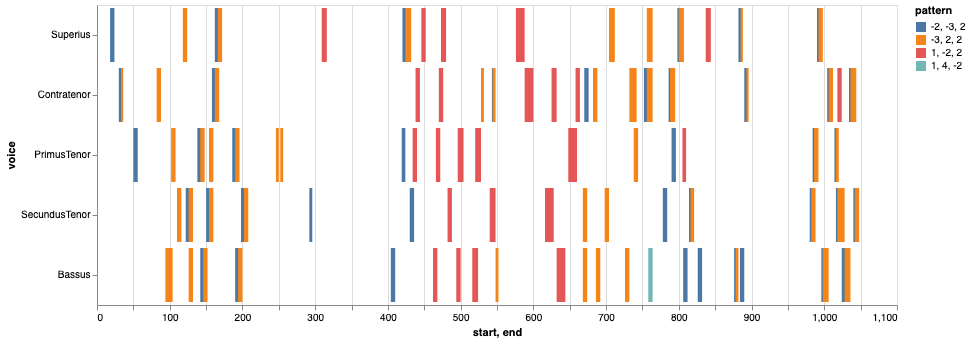

{'title': 'Missa Confitemini: Kyrie', 'composer': 'Pierre Colin', 'date': 1556}


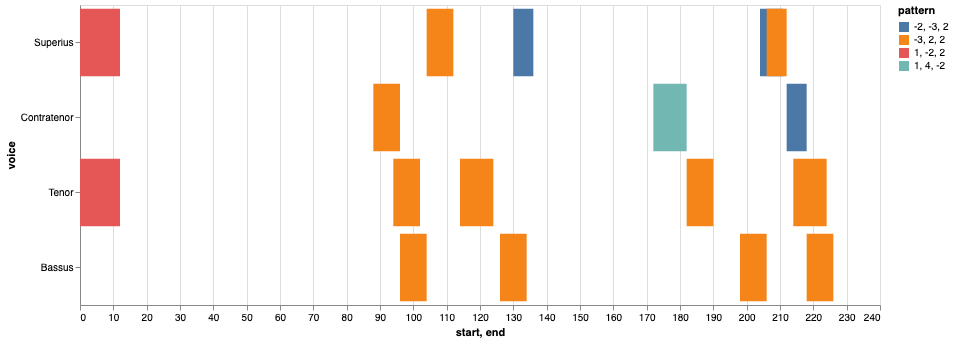

{'title': 'Veni speciosam', 'composer': 'Johannes Lupi', 'date': 1542}


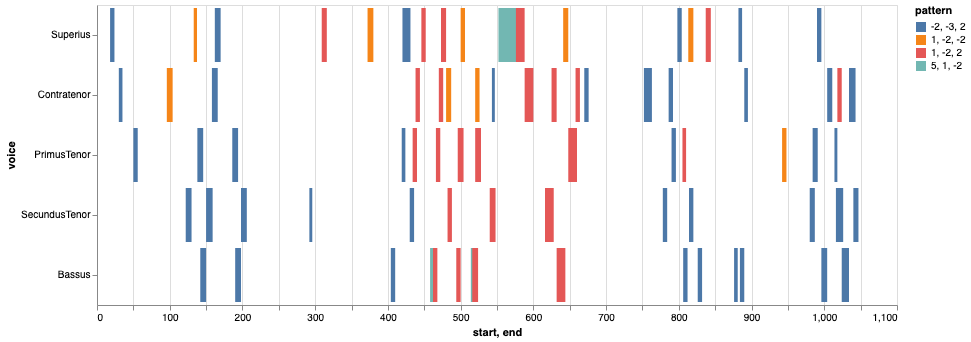

{'title': 'Missa Confitemini: Gloria', 'composer': 'Pierre Colin', 'date': 1556}


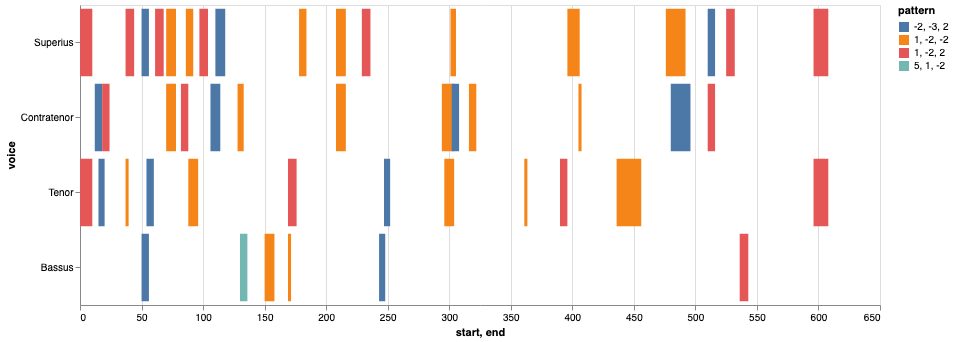

{'title': 'Veni speciosam', 'composer': 'Johannes Lupi', 'date': 1542}


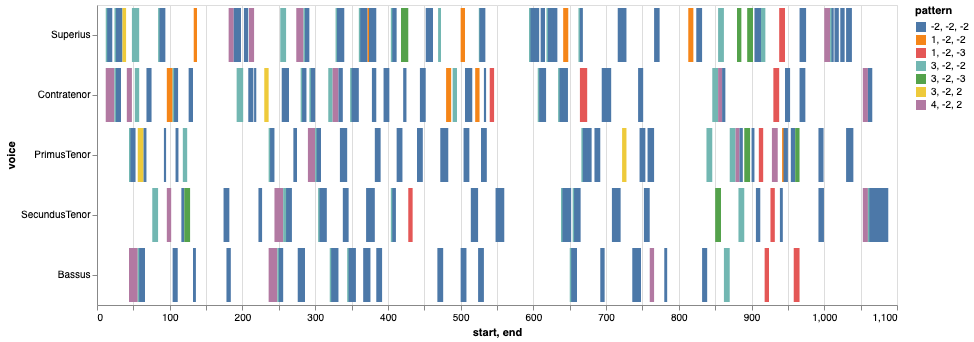

{'title': 'Missa Confitemini: Credo', 'composer': 'Pierre Colin', 'date': 1556}


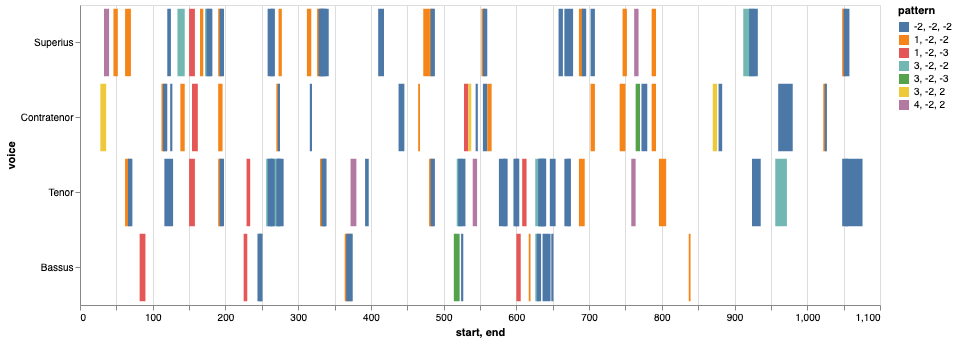

{'title': 'Veni speciosam', 'composer': 'Johannes Lupi', 'date': 1542}


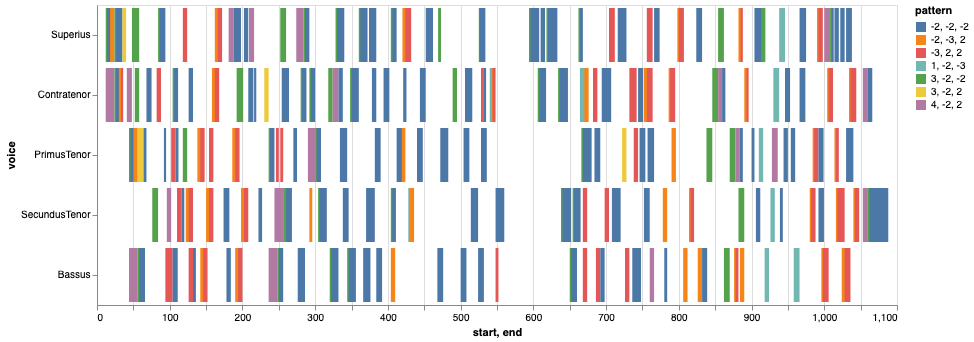

{'title': 'Missa Confitemini: Sanctus', 'composer': 'Pierre Colin', 'date': 1556}


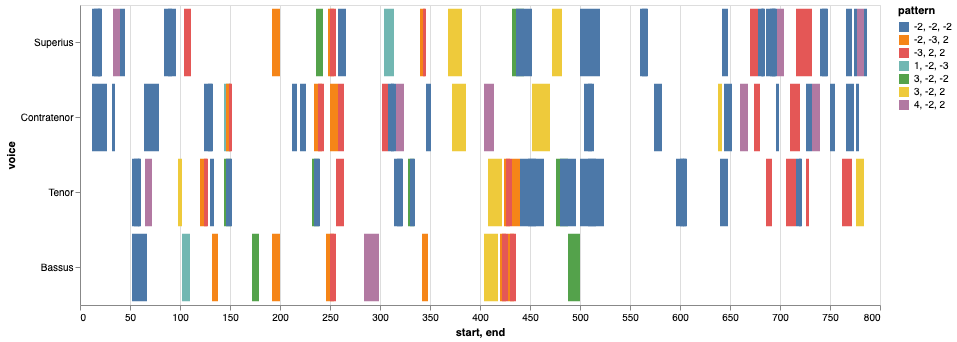

{'title': 'Veni speciosam', 'composer': 'Johannes Lupi', 'date': 1542}


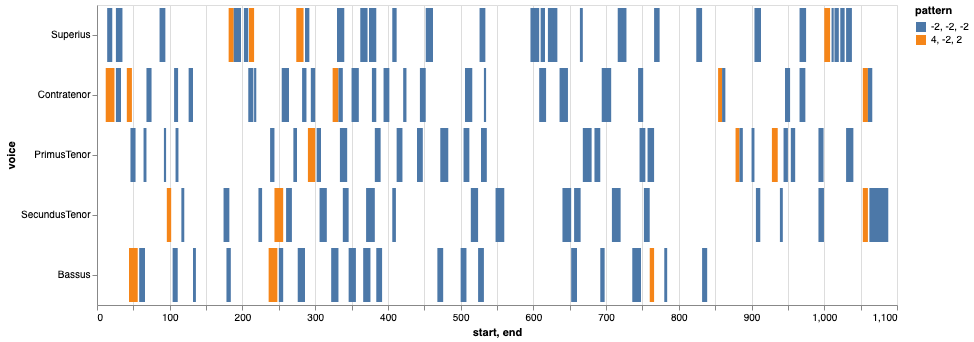

{'title': 'Missa Confitemini: Agnus Dei', 'composer': 'Pierre Colin', 'date': 1556}


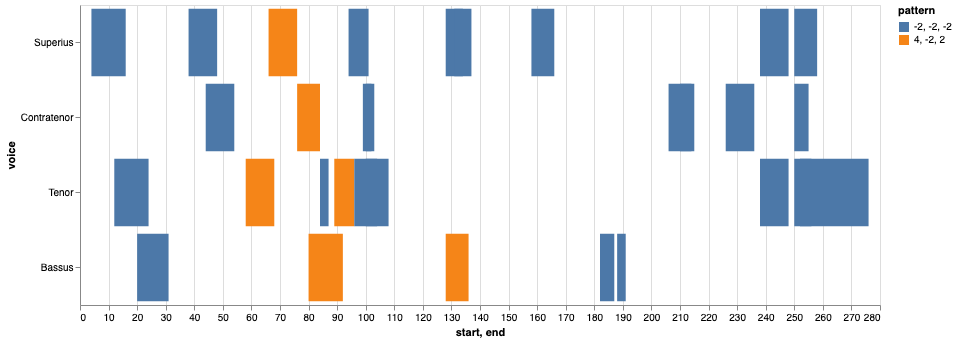

In [18]:

# find entries for model

model = importScore(file_list[5])
nr = model.notes(combineUnisons=combineUnisons)
mel = model.melodic(df=nr, kind=kind, compound=False, unit=0, end=False)
mod_mel_ngrams = model.ngrams(df=mel, n=n, exclude=['Rest'])
mod_entry_ngrams = model.entries(df=mel, n=n, thematic=thematic, anywhere=anywhere, exclude=['Rest'])
mod_mel_ngrams_duration = model.durations(df=mel, n=n, mask_df=mod_entry_ngrams)
mod_entries_stack = list(mod_entry_ngrams.stack().unique())

# find entries mass movements:
mass_movements = file_list[:5] + file_list[6:]
for movement in mass_movements:       
    m_movement = importScore(movement)
    nr = m_movement.notes(combineUnisons=combineUnisons)
    mel = m_movement.melodic(df=nr, kind=kind, compound=False, unit=0, end=False)
    mass_mvmt_mel_ngrams = m_movement.ngrams(df=mel, n=n)
    mass_mvmt_entries = m_movement.entries(df=mel, n=n, thematic=thematic, anywhere=anywhere)
    mass_mvmt_mel_ngrams_duration = m_movement.durations(df=mel, n=n, mask_df=mass_mvmt_entries)
    mass_mvmt_entries_stack = mass_mvmt_entries.stack()
    
    
    # find shared entries
    shared_entries = list(set(mass_mvmt_entries_stack).intersection(mod_entries_stack))

    # or instead focus on one soggetto
    # in this case update code below, replacing 'shared_entries' with 'selected_entries'
    # selected_entries = [('-2', '3', '-2')]
    
    # print model metadata and chart
    print(model.metadata)
    # print(shared_entries)
    display(viz.plot_ngrams_heatmap(mod_entry_ngrams, mod_mel_ngrams_duration, 
                        selected_patterns=shared_entries,
                        voices=[], includeCount=False))
    
    
    # # print mass movement metadata and chart
    print(m_movement.metadata)
    display(viz.plot_ngrams_heatmap(mass_mvmt_entries, mass_mvmt_mel_ngrams_duration, 
                                selected_patterns=shared_entries,
                                voices=[], includeCount=False)) 

## Level 2: Exploring Cadences

Here we can look at the cadences in a single piece, or across several of them at once.

Just two pieces for now


In [6]:

file_list = glob.glob('Music_Files/*')
file_list = sorted(file_list[0:5])
corpus = CorpusBase(file_list)

#select function.  remember to omit "()"
func = ImportedPiece.cadences

#run function on each piece; be sure to include keyword arguments
list_of_dfs = corpus.batch(func = func, kwargs = {'keep_keys': True}, metadata = True)

#concatenate the resulting dataframes into one
corpus_cadences = pd.concat(list_of_dfs, ignore_index = False)

# new order for columns:
col_list = ['Composer', 'Title', 'Measure', 'Beat', 'Pattern', 'CadType', 'Tone','CVFs',
                'LeadingTones', 'Sounding', 'Low','RelLow','RelTone',
                'Progress','SinceLast','ToNext']

corpus_cadences = corpus_cadences[col_list]

# show the results
corpus_cadences.head()


,Composer,Title,Measure,Beat,Pattern,CadType,Tone,CVFs,LeadingTones,Sounding,Low,RelLow,RelTone,Progress,SinceLast,ToNext
60.0,Pierre de Manchicourt,Missa Quo abiit dilectus tuus: Agnus Dei,8.0,3.0,C2z,Abandoned Clausula Vera,G,zC,0.0,3.0,G3,P1,P8,0.083333,60.0,4.0
64.0,Pierre de Manchicourt,Missa Quo abiit dilectus tuus: Agnus Dei,9.0,1.0,C1T-2,Clausula Vera,D,TC,1.0,4.0,B-3,m3,P5,0.088889,4.0,16.0
80.0,Pierre de Manchicourt,Missa Quo abiit dilectus tuus: Agnus Dei,11.0,1.0,c-1x,Abandoned Authentic,NaN,cx,-1.0,1.0,A3,M2,NaN,0.111111,16.0,16.0
96.0,Pierre de Manchicourt,Missa Quo abiit dilectus tuus: Agnus Dei,13.0,1.0,C2T-2,Clausula Vera,G,CT,0.0,4.0,E3,-m3,P8,0.133333,16.0,58.0
154.0,Pierre de Manchicourt,Missa Quo abiit dilectus tuus: Agnus Dei,20.0,2.0,C2T-2,Clausula Vera,D,TC,0.0,4.0,D3,-P4,P5,0.213889,58.0,6.0


### Level 3: A Chart of Types and Tones



/Users/rfreedma/anaconda3/envs/intervals/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



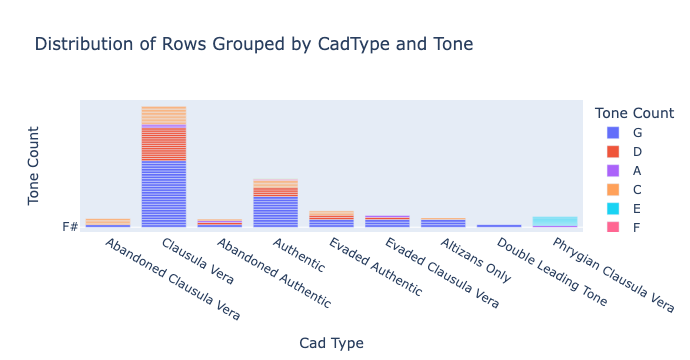

In [7]:
filtered_df = corpus_cadences[['CadType', 'Tone']]

# Create the bar chart
fig = px.bar(filtered_df, x='CadType', y='Tone', color='Tone',
             labels={'CadType':'Cad Type', 'Tone':'Tone Count'},
             title='Distribution of Rows Grouped by CadType and Tone')

# Show the plot
fig.show()

### Level 3:  Show The Cadences as a Radar Plot

If `combinedType` is `True` you will see all the cadence subtype details.
If `displayAll` is `True` you will see all possible cadence tones.

```
corpus.compareCadenceRadarPlots(
                                combinedType = True, 
                                displayAll = False, 
                                renderer = "iframe")
```

No cadences found in the piece: IX - In solemnitatibus et festis B. M. V. (Cum iubilo) - Kyrie


/Users/rfreedma/anaconda3/envs/intervals/lib/python3.10/site-packages/plotly/express/_core.py:2065: FutureWarning:

When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.



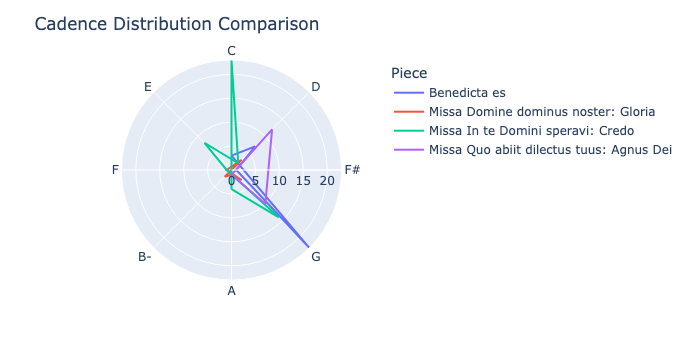

In [8]:
corpus.compareCadenceRadarPlots(
                                combinedType = False, 
                                displayAll = False, 
                                renderer = "iframe")


###  Network of Cadences

In [9]:
# Create Edges Based on CadType
edges = []
for cad_type, group in corpus_cadences.groupby('CVFs'):
    titles = group['Title'].unique()
    for i in range(len(titles)):
        for j in range(i+1, len(titles)):
            edges.append((titles[i], titles[j]))

# Create Nodes and Edges
G = nx.Graph()

# Add nodes
G.add_nodes_from(corpus_cadences['Title'].unique())

# # Add edges
G.add_edges_from(edges)

G = add_communities(G)


# # set physics
cmap = Network(notebook=True,
                   width="600",
                          height="600",
                          bgcolor="black", 
                          font_color="white")
    # Set the physics layout of the network
cmap.set_options("""
{
"physics": {
"enabled": true,
"forceAtlas2Based": {
    "springLength": 1
},
"solver": "forceAtlas2Based"
}
}
""")

cmap.from_nx(G)
# # return the network
cmap.show("final_topic_pairs.html")




### Cadence Progress Plots

Use `Music_Files/*1*.mei` for Kyrie, `Music_Files/*2*.mei` for Gloria, etc.

In [1]:


# model =  'Music_Files/Daser_Motette_Ecce-nunc_E.mei'
file_paths = glob.glob('Music_Files/*0006_1*')
corpus = CorpusBase(file_paths)
corpus.compareCadenceProgressPlots(includeType = True)


NameError: name 'glob' is not defined

## Corpus P Types as Network

First we need to get all of the P Types in our corpus

In [78]:
file_list = glob.glob('Music_Files/*0006*')
file_list = sorted(file_list)
corpus = CorpusBase(file_list)

#select function.  remember to omit "()"
func = ImportedPiece.presentationTypes

#run function on each piece; be sure to include keyword arguments
list_of_dfs = corpus.batch(func = func, kwargs = {'head_flex': 0,
                                                  'melodic_ngram_length' : 3,
                                                  'limit_to_entries' : True,
                                                  'include_hidden_types' : True,
                                                  'head_flex' : 0}, metadata = True)

#concatenate the resulting dataframes into one
corpus_pts = pd.concat(list_of_dfs, ignore_index = False)
corpus_pts['Melodic_Entry_Intervals'] = corpus_pts['Melodic_Entry_Intervals'].apply(lambda x: '_'.join(x))


corpus_pts['Soggetti'] = corpus_pts['Soggetti'].apply(lambda x: '_'.join(map(str, x[0])))
corpus_pts['combined'] = corpus_pts['Soggetti'] + corpus_pts['Melodic_Entry_Intervals']
corpus_pts.head(5)

,Composer,Title,First_Offset,Measures_Beats,Melodic_Entry_Intervals,Offsets,Soggetti,Time_Entry_Intervals,Voices,Presentation_Type,Number_Entries,Flexed_Entries,Parallel_Entries,Parallel_Voice,Progress,Date,combined
0,Jean Guyon,Guyon Missa Je suis déshéritée: Kyrie,0.0,"[1.0/1.0, 1.0/3.0, 3.0/1.0, 4.0/3.0, 5.0/1.0]",P1_P8_P-8_P5,"[0.0, 4.0, 16.0, 28.0, 32.0]",1_1_3,"[4.0, 12.0, 12.0, 4.0]","[[Bassus], [Tenor], [Superius], [Tenor], [Cont...",FUGA,5,False,False,None,0.0,1556,1_1_3P1_P8_P-8_P5
1,Jean Guyon,Guyon Missa Je suis déshéritée: Kyrie,0.0,"[1.0/1.0, 3.0/1.0, 5.0/1.0]",P8_P-4,"[0.0, 16.0, 32.0]",1_1_3,"[16.0, 16.0]","[[Bassus], [Superius], [Contratenor]]",PEN,3,False,False,None,0.0,1556,1_1_3P8_P-4
2,Jean Guyon,Guyon Missa Je suis déshéritée: Kyrie,0.0,"[1.0/1.0, 1.0/3.0, 3.0/1.0, 4.0/3.0]",P1_P8_P-8,"[0.0, 4.0, 16.0, 28.0]",1_1_3,"[4.0, 12.0, 12.0]","[[Bassus], [Tenor], [Superius], [Tenor]]",FUGA,4,False,False,None,0.0,1556,1_1_3P1_P8_P-8
3,Jean Guyon,Guyon Missa Je suis déshéritée: Kyrie,0.0,"[1.0/1.0, 1.0/3.0, 3.0/1.0, 5.0/1.0]",P1_P8_P-4,"[0.0, 4.0, 16.0, 32.0]",1_1_3,"[4.0, 12.0, 16.0]","[[Bassus], [Tenor], [Superius], [Contratenor]]",FUGA,4,False,False,None,0.0,1556,1_1_3P1_P8_P-4
4,Jean Guyon,Guyon Missa Je suis déshéritée: Kyrie,0.0,"[1.0/1.0, 1.0/3.0, 4.0/3.0, 5.0/1.0]",P1_P1_P5,"[0.0, 4.0, 28.0, 32.0]",1_1_3,"[4.0, 24.0, 4.0]","[[Bassus], [Tenor], [Tenor], [Contratenor]]",ID,4,False,False,None,0.0,1556,1_1_3P1_P1_P5


## Network of P Types

And now create a network.  The nodes will represent the pieces.  The edges connect pieces that share the same p type.

In this case we are using the 'combined' p type (with information about the soggetto and the melodic intervals of imitation) as the basis of our edges:

These combined types look like this:

`-3_2_2P-4_P-5`

And now the groupby code:

```python
corpus_pts.groupby('combined')
```

In [81]:
# Create Edges Based on ptype
edges = []
for pt, group in corpus_pts.groupby('Melodic_Entry_Intervals'):
    titles = group['Title'].unique()
    for i in range(len(titles)):
        for j in range(i+1, len(titles)):
            edges.append((titles[i], titles[j]))


G = nx.Graph()
G.add_nodes_from(corpus_pts['Title'])
G.add_edges_from(edges)
G = add_communities(G)

# set physics
cmap = Network(notebook=True,
                   width="1000",
                          height="750",
                          bgcolor="black", 
                          font_color="white")
cmap.set_options("""
{
"physics": {
"enabled": true,
"forceAtlas2Based": {
    "springLength": 1
},
"solver": "forceAtlas2Based"
}
}
""")

cmap.from_nx(G)

# return the network
cmap.show("final_topic_pairs.html")
